# Genome PRD v1 — 01 Training dataset

Validate the materialized v2 dataset against the canonical 30-feature PRD contract. Regenerate an absent or old 25-feature artifact with `python -m src.features.materialize` from the repository root. Saved outputs in this notebook predate the 30-feature extension; rerun to obtain current results.

In [21]:
from pathlib import Path
import gc
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq

here = Path.cwd().resolve()
ROOT = next(path for path in (here, *here.parents) if (path / 'src/training/prd_config.py').is_file())
sys.path.insert(0, str(ROOT))
from src.features.genome import GENOME_FEATURE_COLUMNS, build_genome_lookup
from src.training import prd_config
from src.training.modeling import validate_v2

## Contract and artifact schema

In [22]:
assert len(prd_config.PRD_FEATURES) == 30
assert prd_config.FEATURE_ARTIFACT_PATH.is_file(), 'Run: python -m src.features.materialize'
metadata = json.loads(prd_config.FEATURE_METADATA_PATH.read_text())
assert metadata['featureContractVersion'] == prd_config.FEATURE_CONTRACT_VERSION
schema = pq.ParquetFile(prd_config.FEATURE_ARTIFACT_PATH).schema_arrow
assert metadata['predictorNames'] == list(prd_config.PRD_FEATURES)
assert metadata['rowCount'] == pq.ParquetFile(prd_config.FEATURE_ARTIFACT_PATH).metadata.num_rows
assert all(name in schema.names for name in prd_config.PRD_FEATURES)
assert {name: metadata['outputSchema'][name] for name in prd_config.PRD_FEATURES} == prd_config.PRD_FEATURE_DTYPES
display(pd.DataFrame({'feature': prd_config.PRD_FEATURES, 'dtype': [prd_config.PRD_FEATURE_DTYPES[name] for name in prd_config.PRD_FEATURES]}))

,feature,dtype
0,global_rating_count,uint64
1,global_mean_rating,float32
2,user_rating_count,uint64
3,user_mean_rating,float32
4,user_rating_std_pop,float32
5,user_seconds_since_last_rating,float64
6,movie_rating_count,uint64
7,movie_mean_rating,float32
8,movie_rating_std_pop,float32
9,movie_rating_count_30d,uint64


## Full artifact validation and summary

In [23]:
validation = validate_v2(None, prd_config.FEATURE_ARTIFACT_PATH, prd_config.FEATURE_METADATA_PATH, prd_config.RATINGS_SOURCE_PATH)
display(pd.Series({
    'rows': validation['row_count'],
    'predictors': validation['predictor_count'],
    'target_prevalence': validation['target_prevalence'],
    'rating_event_ids_complete_unique': validation['rating_event_ids_complete_unique'],
    'timestamps_nondecreasing': validation['timestamps_nondecreasing'],
}).to_frame('value'))
display(pd.Series(validation['genome_null_rates'], name='null_rate').rename_axis('Genome feature').to_frame())
assert set(validation['genome_null_rates']) == set(GENOME_FEATURE_COLUMNS)

,value
rows,20000263
predictors,25
target_prevalence,0.499764
rating_event_ids_complete_unique,True
timestamps_nondecreasing,True


,null_rate
Genome feature,
genome_user_positive_cosine,0.034133
genome_user_negative_cosine,0.032089
genome_preference_margin,0.042514
genome_nearest_liked_similarity,0.034133
genome_top5_liked_similarity,0.034133
genome_movie_relevance_mean,0.009991
genome_movie_relevance_std,0.009991
genome_movie_top10_mean,0.009991


## Exploratory analysis of key model features

The executable source of truth for the model inputs is `prd_config.PRD_FEATURES`; the saved model results are checked against that contract below. The selected columns combine high-gain predictors with representative user, movie, user-genre, rolling-window, and Genome feature families. This is descriptive EDA of the already materialized dataset—not feature selection and not a change to dataset construction. Associations with the target are descriptive and should not be interpreted causally.

The full-data summary is computed one column at a time to keep peak memory bounded. Histograms and target-conditioned plots use a deterministic sample for responsiveness. Histogram axes for continuous variables stop at the full-data 99th percentile; count variables are shown as `log1p(count)`. Neither choice clips or transforms the stored data.

In [24]:
model_results = json.loads(prd_config.PRD_RESULTS_PATH.read_text())
assert tuple(model_results['feature_columns']) == prd_config.PRD_FEATURES
gain_by_feature = {row['feature']: row['gain'] for row in model_results['gain_importance']}

KEY_FEATURES = (
    'user_rating_count',
    'user_mean_rating',
    'user_rating_std_pop',
    'movie_rating_count',
    'movie_mean_rating',
    'movie_rating_count_30d',
    'user_target_genre_rating_count',
    'user_target_genre_mean_rating',
    'genome_preference_margin',
    'genome_user_positive_cosine',
    'genome_nearest_liked_similarity',
)
assert set(KEY_FEATURES).issubset(prd_config.PRD_FEATURES)
training_rows_before_eda = pq.ParquetFile(prd_config.FEATURE_ARTIFACT_PATH).metadata.num_rows

feature_selection = pd.DataFrame({
    'dtype': [prd_config.PRD_FEATURE_DTYPES[name] for name in KEY_FEATURES],
    'model_gain': [gain_by_feature[name] for name in KEY_FEATURES],
}, index=pd.Index(KEY_FEATURES, name='feature')).sort_values('model_gain', ascending=False)
display(feature_selection)

,dtype,model_gain
feature,,
genome_preference_margin,float32,8434.924805
movie_mean_rating,float32,4103.211914
user_target_genre_mean_rating,float32,3948.826904
user_mean_rating,float32,3811.644531
genome_user_positive_cosine,float32,1110.785522
genome_nearest_liked_similarity,float32,721.757385
user_rating_count,uint64,516.495972
user_rating_std_pop,float32,490.389130
user_target_genre_rating_count,uint64,249.088074


In [25]:
quantile_levels = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
summary_rows = []
for feature_name in KEY_FEATURES:
    values = pq.read_table(
        prd_config.FEATURE_ARTIFACT_PATH, columns=[feature_name]
    )[feature_name].combine_chunks()
    quantiles = pc.quantile(values, q=quantile_levels).to_pylist()
    summary_rows.append({
        'feature': feature_name,
        'dtype': prd_config.PRD_FEATURE_DTYPES[feature_name],
        'count': len(values) - values.null_count,
        'missing_pct': 100 * values.null_count / len(values),
        'mean': pc.mean(values).as_py(),
        'std': pc.stddev(values, ddof=1).as_py(),
        'min': pc.min(values).as_py(),
        **{f'p{int(level * 100):02d}': value for level, value in zip(quantile_levels, quantiles)},
        'max': pc.max(values).as_py(),
        'n_unique': pc.count_distinct(values).as_py(),
    })
    del values
    gc.collect()

feature_summary = pd.DataFrame(summary_rows).set_index('feature')
display(feature_summary)

,dtype,count,missing_pct,mean,std,min,p25,p50,p75,p90,p95,p99,max,n_unique
feature,,,,,,,,,,,,,,
user_rating_count,uint64,20000263,0.000000,254.831463,410.582294,0.000000,39.000000,115.000000,301.000000,640.000000,957.000000,1942.000000,9253.000000,9254
user_mean_rating,float32,20000263,0.000000,3.553494,0.468647,0.500000,3.285714,3.578592,3.863636,4.107143,4.250000,4.521739,5.000000,1425431
user_rating_std_pop,float32,20000263,0.000000,0.910692,0.269474,0.000000,0.759836,0.910187,1.071779,1.230978,1.335137,1.549317,2.250000,5007740
movie_rating_count,uint64,20000263,0.000000,6739.691270,9029.228089,0.000000,879.000000,3223.000000,8846.000000,18285.000000,25890.000000,42728.380000,67309.000000,67310
movie_mean_rating,float32,20000263,0.000000,3.574215,0.487685,0.500000,3.293255,3.653061,3.925444,4.134080,4.231092,4.407740,5.000000,5508671
movie_rating_count_30d,uint64,20000263,0.000000,181.032810,385.339482,0.000000,21.000000,63.000000,156.000000,381.000000,791.000000,2215.000000,3724.000000,3725
user_target_genre_rating_count,uint64,20000263,0.000000,173.267827,283.513190,0.000000,25.000000,79.000000,204.000000,431.000000,651.000000,1336.000000,13036.000000,6334
user_target_genre_mean_rating,float32,20000263,0.000000,3.574688,0.517899,0.500000,3.285714,3.602339,3.916667,4.178571,4.336364,4.666667,5.000000,1079817
genome_preference_margin,float32,19149978,4.251369,0.001801,0.059271,-0.512552,-0.031969,0.001948,0.034766,0.070314,0.096119,0.163194,0.497842,17034610


Counts span orders of magnitude, so their log-scale views make the body of each distribution legible; the untransformed percentiles remain visible in the summary table. Missing Genome values are retained because the model's contract delegates `NaN` handling to XGBoost.

In [26]:
rating_values = pd.read_parquet(
    prd_config.RATINGS_SOURCE_PATH, columns=['rating']
)["rating"].to_numpy(copy=False)
assert len(rating_values) == training_rows_before_eda

sample_target_rows = 200_000
sample_stride = max(1, training_rows_before_eda // sample_target_rows)
sample_parts = []
sample_columns = ['ratingEventId', *KEY_FEATURES]
for batch in pq.ParquetFile(prd_config.FEATURE_ARTIFACT_PATH).iter_batches(
    batch_size=250_000, columns=sample_columns
):
    part = batch.to_pandas()
    keep = part['ratingEventId'].mod(sample_stride).eq(0)
    if keep.any():
        part = part.loc[keep].copy()
        positions = part['ratingEventId'].to_numpy(dtype=np.uint64, copy=False) - 1
        part['target'] = (
            rating_values[positions] >= prd_config.PRD_TARGET_THRESHOLD
        ).astype(np.int8)
        sample_parts.append(part)
eda_sample = pd.concat(sample_parts, ignore_index=True)
print(f'Deterministic plotting sample: {len(eda_sample):,} rows (every {sample_stride}th ratingEventId)')

Deterministic plotting sample: 200,002 rows (every 100th ratingEventId)


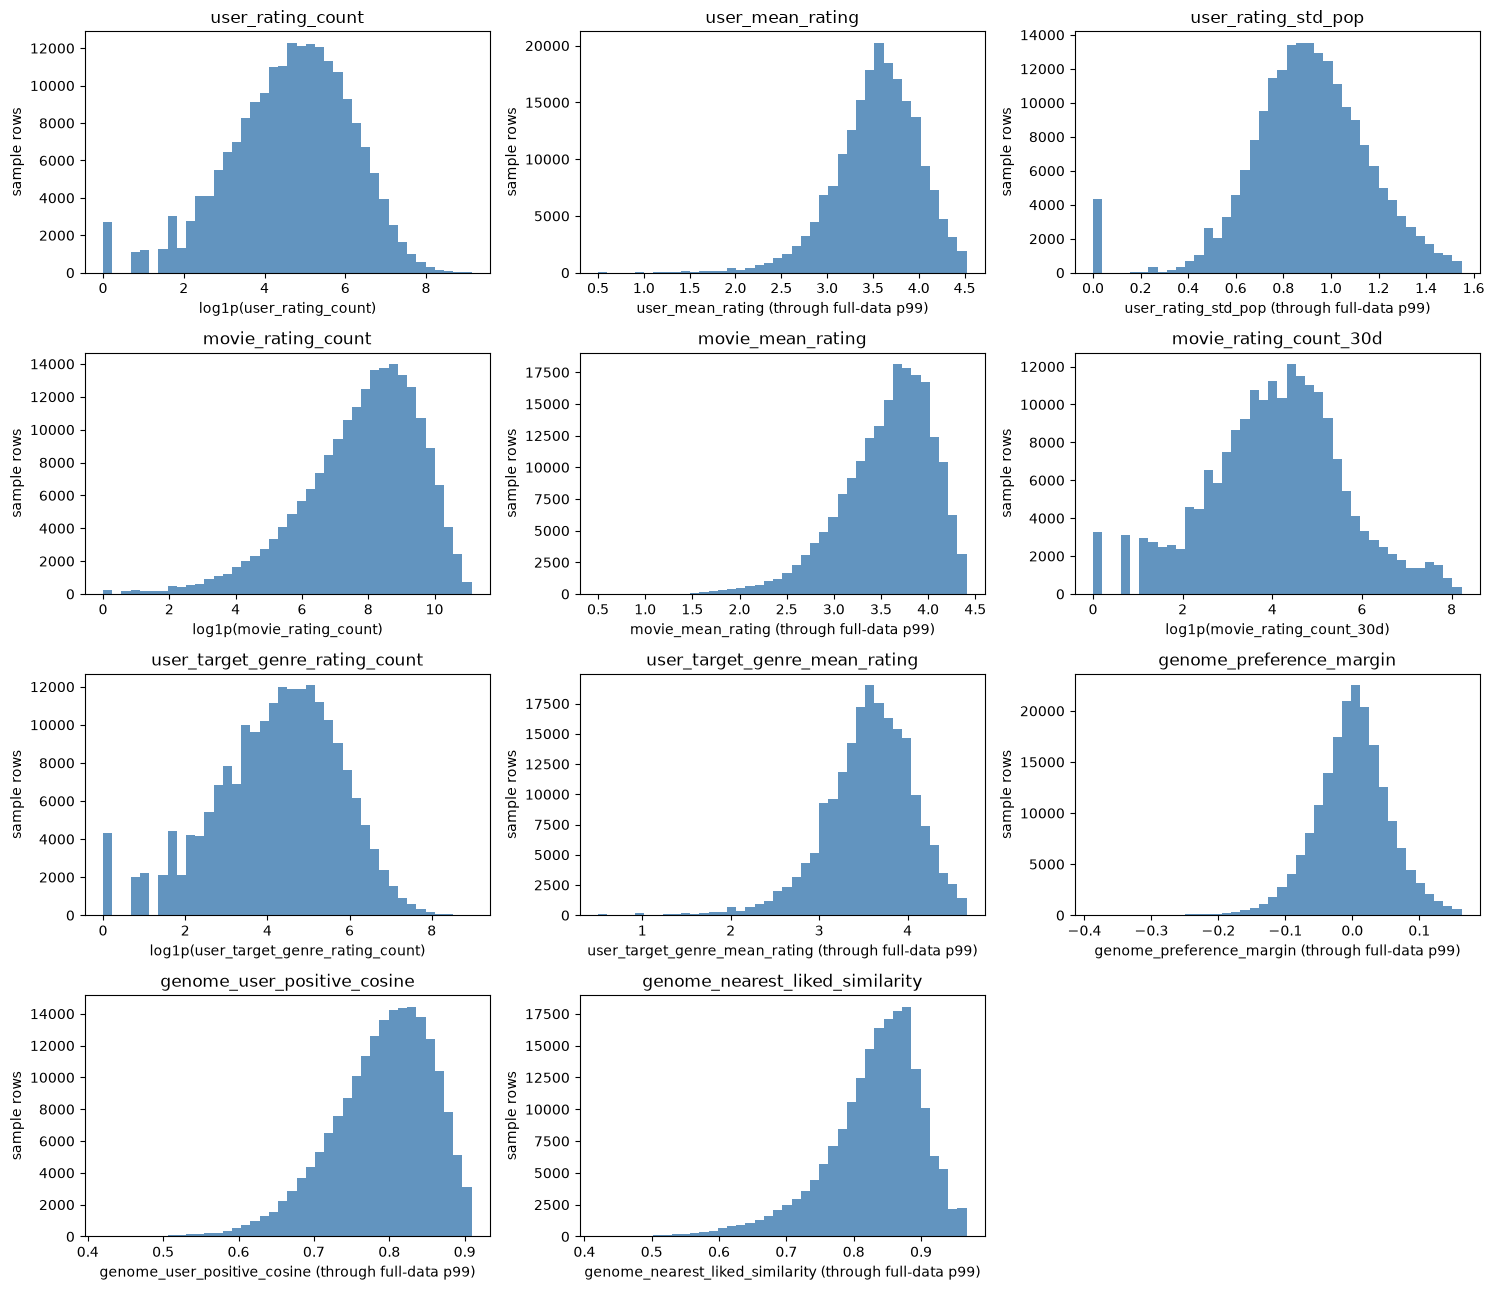

In [27]:
COUNT_FEATURES = {
    'user_rating_count', 'movie_rating_count', 'movie_rating_count_30d',
    'user_target_genre_rating_count',
}
figure, axes = plt.subplots(4, 3, figsize=(15, 13))
for axis, feature_name in zip(axes.flat, KEY_FEATURES):
    plot_values = eda_sample[feature_name].dropna()
    if feature_name in COUNT_FEATURES:
        axis.hist(np.log1p(plot_values), bins=40, color='steelblue', alpha=0.85)
        axis.set_xlabel(f'log1p({feature_name})')
    else:
        upper = feature_summary.loc[feature_name, 'p99']
        plot_values = plot_values[plot_values <= upper]
        axis.hist(plot_values, bins=40, color='steelblue', alpha=0.85)
        axis.set_xlabel(f'{feature_name} (through full-data p99)')
    axis.set_ylabel('sample rows')
    axis.set_title(feature_name)
axes.flat[-1].axis('off')
figure.tight_layout()
plt.show()

### Descriptive relationship with the target

The compact summaries and boxplots below compare a few especially interpretable predictors between low (`target = 0`) and high (`target = 1`) ratings. They use the same deterministic plotting sample and describe association only.

user_mean_rating                               movie_mean_rating  \
                  count      mean       std    median             count   
target                                                                    
0                100239  3.402491  0.463862  3.447368            100239   
1                 99763  3.703911  0.424945  3.722222             99763   

                                     genome_preference_margin            \
            mean       std    median                    count      mean   
target                                                                    
0       3.393736  0.505355  3.454545                    95461 -0.022077   
1       3.754088  0.392843  3.805746                    96021  0.025542   

                            
             std    median  
target                      
0       0.054514 -0.019410  
1       0.053973  0.021413

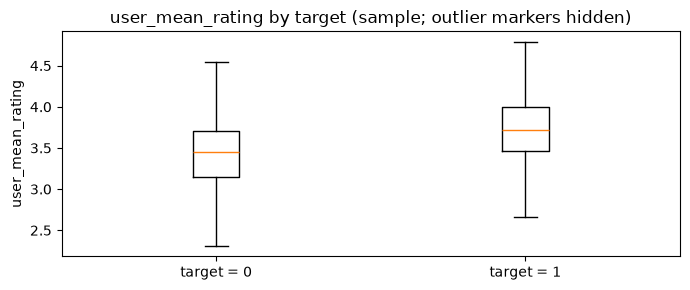

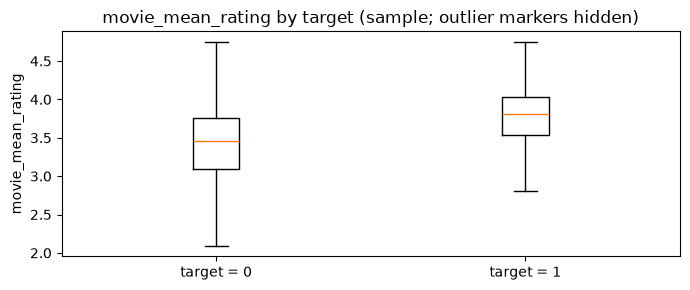

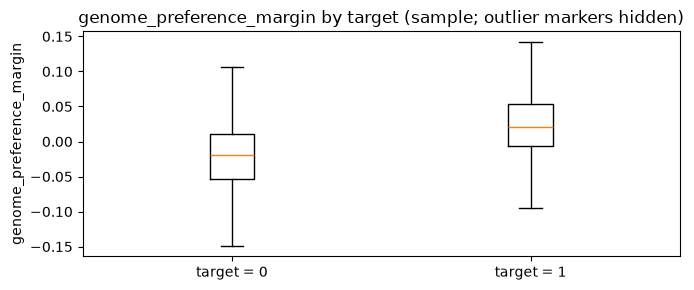

In [28]:
TARGET_RELATION_FEATURES = (
    'user_mean_rating', 'movie_mean_rating', 'genome_preference_margin'
)
target_summary = (
    eda_sample.groupby('target')[list(TARGET_RELATION_FEATURES)]
    .agg(['count', 'mean', 'std', 'median'])
)
display(target_summary)

for feature_name in TARGET_RELATION_FEATURES:
    figure, axis = plt.subplots(figsize=(7, 3))
    groups = [
        eda_sample.loc[eda_sample['target'].eq(label), feature_name].dropna()
        for label in (0, 1)
    ]
    axis.boxplot(groups, tick_labels=['target = 0', 'target = 1'], showfliers=False)
    axis.set_ylabel(feature_name)
    axis.set_title(f'{feature_name} by target (sample; outlier markers hidden)')
    figure.tight_layout()
    plt.show()

## Worked example: validating user historical features

The actual mean feature is named `user_mean_rating`; `user_rating_mean` is not part of this contract. We choose a user reproducibly from those with 20–100 events, ordered by distance from the median activity in that range and then by `userId`. The first candidate whose complete history has one unique timestamp per event is selected. The focal observation is the event at the midpoint of that history. This produces a readable, one-rating-at-a-time example without choosing an extreme user.

In [29]:
feature_user_ids = pd.read_parquet(
    prd_config.FEATURE_ARTIFACT_PATH, columns=['userId']
)["userId"]


user_event_counts = feature_user_ids.value_counts(sort=False)
eligible_counts = user_event_counts[user_event_counts.between(20, 100)]
assert not eligible_counts.empty
eligible_median = float(eligible_counts.median())
candidate_users = (
    eligible_counts.rename('event_count').rename_axis('userId').reset_index()
    .assign(distance=lambda frame: (frame['event_count'] - eligible_median).abs())
    .sort_values(['distance', 'userId'], kind='stable')
)
example_columns_to_read = [
    'ratingEventId', 'userId', 'movieId', 'timestamp',
    'user_rating_count', 'user_mean_rating',
    'genome_user_positive_cosine', 'genome_user_negative_cosine',
    'genome_preference_margin',
]
example_user_id = None
example_events = None
for candidate in candidate_users.head(500).itertuples(index=False):
    candidate_events = pd.read_parquet(
        prd_config.FEATURE_ARTIFACT_PATH,
        columns=example_columns_to_read,
        filters=[('userId', '==', int(candidate.userId))],
    ).sort_values(['timestamp', 'ratingEventId'], kind='stable').reset_index(drop=True)
    if candidate_events['timestamp'].is_unique:
        example_user_id = int(candidate.userId)
        example_events = candidate_events
        break
assert example_user_id is not None and example_events is not None
del feature_user_ids, user_event_counts, eligible_counts, candidate_users
gc.collect()

event_positions = example_events['ratingEventId'].to_numpy(dtype=np.uint64, copy=False) - 1
example_events['rating'] = rating_values[event_positions]
example_events['target'] = (
    example_events['rating'] >= prd_config.PRD_TARGET_THRESHOLD
).astype(np.int8)

assert example_events['timestamp'].is_unique
focal_position = len(example_events) // 2
focal_event = example_events.iloc[focal_position]
focal_timestamp = focal_event['timestamp']

window_start = max(0, focal_position - 4)
window_stop = min(len(example_events), focal_position + 5)
example_columns = [
    'timestamp', 'movieId', 'rating', 'target',
    'user_rating_count', 'user_mean_rating',
]
print(f'Chosen userId: {example_user_id} ({len(example_events)} events; eligible-range median={eligible_median:g})')
print(f'Unique timestamps: {example_events.timestamp.nunique()} of {len(example_events)} events')
print(f'Focal ratingEventId: {int(focal_event.ratingEventId)} at {focal_timestamp}')
display(example_events.loc[window_start:window_stop - 1, example_columns])

Chosen userId: 801 (41 events; eligible-range median=41)
Unique timestamps: 41 of 41 events
Focal ratingEventId: 119139 at 2007-02-26 20:28:58


,timestamp,movieId,rating,target,user_rating_count,user_mean_rating
16,2007-02-26 20:25:41,527,4.5,1,16,3.156250
17,2007-02-26 20:26:05,858,3.5,0,17,3.235294
18,2007-02-26 20:27:50,36529,3.5,0,18,3.250000
19,2007-02-26 20:27:55,7254,4.5,1,19,3.263158
20,2007-02-26 20:28:58,4963,2.5,0,20,3.325000
21,2007-02-26 20:30:39,3578,4.0,1,21,3.285714
22,2007-02-26 20:31:17,44191,3.5,0,22,3.318182
23,2007-02-26 20:31:22,6333,2.5,0,23,3.326087
24,2007-02-26 20:31:33,33166,4.5,1,24,3.291667


In [41]:
print(f'Manual check user_mean_rating: {(3.325000*20 + 2.5)/21}')

Manual check user_mean_rating: 3.2857142857142856


### Manual strict-prior reconstruction

Only this user's events with `historical_timestamp < t` enter the manual calculation. This user has no repeated timestamps, so the single row exactly at `t` is the current event and is excluded. Its rating becomes part of the historical state only for the next event.

In [31]:
historical_events = example_events.loc[
    example_events['timestamp'] < focal_timestamp,
    ['ratingEventId', 'timestamp', 'movieId', 'rating'],
].copy()
current_timestamp_event = example_events.loc[
    example_events['timestamp'] == focal_timestamp,
    ['ratingEventId', 'timestamp', 'movieId', 'rating',
     'user_rating_count', 'user_mean_rating'],
].copy()

display(historical_events[['timestamp', 'movieId', 'rating']])
display(current_timestamp_event)

manual_count = int(len(historical_events))
manual_mean = float(historical_events['rating'].mean()) if manual_count else np.nan
dataset_count = int(focal_event['user_rating_count'])
dataset_mean = float(focal_event['user_mean_rating'])
count_match = manual_count == dataset_count
mean_match = bool(np.isclose(manual_mean, dataset_mean, rtol=1e-6, atol=1e-6))
validation_table = pd.DataFrame({
    'feature': ['user_rating_count', 'user_mean_rating'],
    'dataset value': [dataset_count, dataset_mean],
    'manually recomputed value': [manual_count, manual_mean],
    'match': [count_match, mean_match],
})
display(validation_table)

,timestamp,movieId,rating
0,2007-02-26 20:06:07,6373,2.5
1,2007-02-26 20:07:13,3173,2.5
2,2007-02-26 20:08:40,8984,1.5
3,2007-02-26 20:09:02,8957,4.5
4,2007-02-26 20:10:02,45499,1.5
5,2007-02-26 20:10:31,36517,4.5
6,2007-02-26 20:10:56,45447,4.0
7,2007-02-26 20:11:17,38061,3.5
8,2007-02-26 20:11:48,6952,3.0
9,2007-02-26 20:12:10,48385,4.5


,ratingEventId,timestamp,movieId,rating,user_rating_count,user_mean_rating
20,119139,2007-02-26 20:28:58,4963,2.5,20,3.325


,feature,dataset value,manually recomputed value,match
0,user_rating_count,20.000,20.000,True
1,user_mean_rating,3.325,3.325,True


In [32]:
# Read-only checks for the strict-prior example and dataset invariants.
assert historical_events['timestamp'].lt(focal_timestamp).all()
assert not historical_events['timestamp'].eq(focal_timestamp).any()
assert int(focal_event['ratingEventId']) not in set(historical_events['ratingEventId'])
assert manual_count == dataset_count
assert np.isclose(manual_mean, dataset_mean, rtol=1e-6, atol=1e-6)
assert example_events['timestamp'].is_unique
assert len(current_timestamp_event) == 1
assert current_timestamp_event['user_rating_count'].eq(manual_count).all()
assert np.isclose(
    current_timestamp_event['user_mean_rating'].to_numpy(dtype=float),
    manual_mean, rtol=1e-6, atol=1e-6,
).all()
assert pq.ParquetFile(prd_config.FEATURE_ARTIFACT_PATH).metadata.num_rows == training_rows_before_eda
print('Strict-prior manual validation: PASS')
print('All timestamps for the selected user are unique: PASS')
print('Current event at t excluded from its own history: PASS')
print('Training dataset row count unchanged: PASS')

Strict-prior manual validation: PASS
All timestamps for the selected user are unique: PASS
Current event at t excluded from its own history: PASS
Training dataset row count unchanged: PASS


Cold start is explicit in this feature contract: when `user_rating_count == 0`, `user_mean_rating` falls back to the strictly prior global mean (and ultimately to the configured global cold-start value for the first global event), rather than becoming `NaN`. The worked validation deliberately uses a non-cold-start event, so its mean is the ordinary mean of the user's strict-prior ratings.

## Temporal view of the worked example

> The feature value attached to an event at time t represents the user's state immediately before t, not after observing the rating at t.

Each marker below is the feature stored on one event. Because this user's timestamps are unique, every subsequent marker reflects exactly one newly incorporated rating. The count therefore increases by one per event.

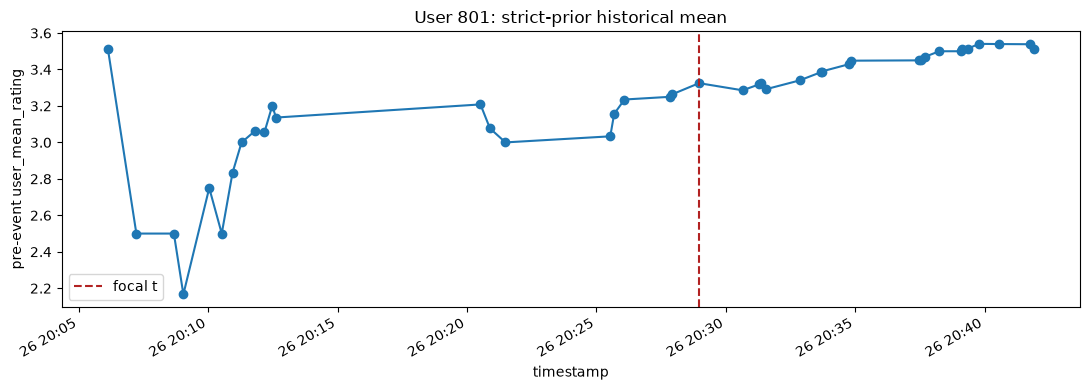

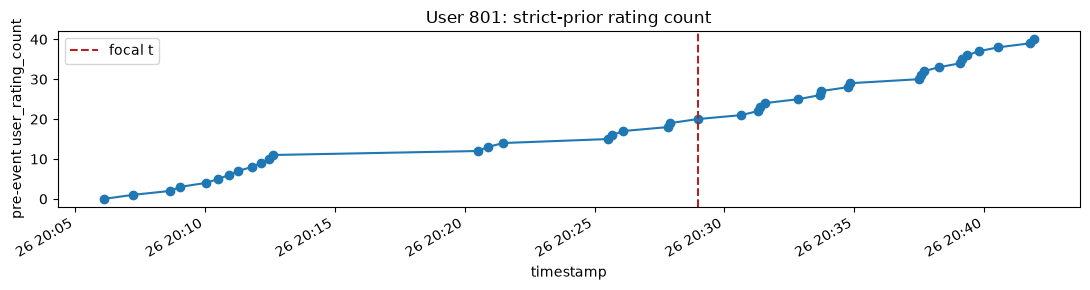

In [33]:
timeline = (
    example_events.groupby('timestamp', as_index=False, sort=True)
    .agg(
        user_mean_rating=('user_mean_rating', 'first'),
        user_rating_count=('user_rating_count', 'first'),
        events_at_timestamp=('ratingEventId', 'size'),
    )
)

figure, axis = plt.subplots(figsize=(11, 4))
axis.plot(timeline['timestamp'], timeline['user_mean_rating'], marker='o', linewidth=1.5)
axis.axvline(focal_timestamp, color='firebrick', linestyle='--', label='focal t')
axis.set_xlabel('timestamp')
axis.set_ylabel('pre-event user_mean_rating')
axis.set_title(f'User {example_user_id}: strict-prior historical mean')
axis.legend()
figure.autofmt_xdate()
figure.tight_layout()
plt.show()

figure, axis = plt.subplots(figsize=(11, 3))
axis.plot(timeline['timestamp'], timeline['user_rating_count'], marker='o', linewidth=1.5)
axis.axvline(focal_timestamp, color='firebrick', linestyle='--', label='focal t')
axis.set_xlabel('timestamp')
axis.set_ylabel('pre-event user_rating_count')
axis.set_title(f'User {example_user_id}: strict-prior rating count')
axis.legend()
figure.autofmt_xdate()
figure.tight_layout()
plt.show()

## Worked example: Genome preference margin end-to-end

This section follows one real training row through the implementation in `src.features.genome`. The code does **not** compute a rating-weighted mean vector. It adds raw Genome vectors to a positive sum (`rating >= 4`) or a negative sum (`rating < 4`). Cosine similarity normalizes those sums by their L2 norms, so the profile direction determines each cosine. The final feature is `genome_user_positive_cosine - genome_user_negative_cosine`. Everything below is read-only.

### A. Which user and movie are we predicting?

We search the moderate-size, unique-timestamp user selected above. A candidate needs a complete, nonzero target-movie Genome vector, a non-null margin, and at least three covered positive and negative movies strictly before `t`. We choose the valid event closest to the middle of the user's history, then break ties by timestamp and `ratingEventId`.

In [34]:
GENOME_SCORES_PATH = ROOT / 'data/processed/genome_scores.parquet'
GENOME_TAGS_PATH = ROOT / 'data/processed/genome_tags.parquet'
MOVIES_PATH = ROOT / 'data/processed/movies.parquet'

genome_scores = pd.read_parquet(GENOME_SCORES_PATH)
genome_lookup = build_genome_lookup(genome_scores)
genome_tags = pd.read_parquet(GENOME_TAGS_PATH, columns=['tagId', 'tag'])
movie_titles = (
    pd.read_parquet(MOVIES_PATH, columns=['movieId', 'title'])
    .set_index('movieId')['title']
)
del genome_scores
gc.collect()

genome_candidate_rows = []
covered_movies = example_events['movieId'].isin(genome_lookup.movie_to_row)
for position, event in example_events.iterrows():
    prior = example_events['timestamp'].lt(event['timestamp'])
    positive_count = int((prior & covered_movies & example_events['rating'].ge(4.0)).sum())
    negative_count = int((prior & covered_movies & example_events['rating'].lt(4.0)).sum())
    if (
        int(event['movieId']) in genome_lookup.movie_to_row
        and pd.notna(event['genome_preference_margin'])
        and positive_count >= 3
        and negative_count >= 3
    ):
        genome_candidate_rows.append({
            'position': position,
            'distance_from_middle': abs(position - len(example_events) / 2),
            'timestamp': event['timestamp'],
            'ratingEventId': int(event['ratingEventId']),
            'positive_history_count': positive_count,
            'negative_history_count': negative_count,
        })
assert genome_candidate_rows
genome_candidate = (
    pd.DataFrame(genome_candidate_rows)
    .sort_values(['distance_from_middle', 'timestamp', 'ratingEventId'], kind='stable')
    .iloc[0]
)
genome_event = example_events.loc[int(genome_candidate['position'])]
genome_t = genome_event['timestamp']
genome_target_movie_id = int(genome_event['movieId'])

selected_observation = pd.Series({
    'ratingEventId': int(genome_event['ratingEventId']),
    'userId': int(genome_event['userId']),
    'movieId': genome_target_movie_id,
    'title': movie_titles.get(genome_target_movie_id, '(title unavailable)'),
    'timestamp': genome_t,
    'rating': float(genome_event['rating']),
    'target': int(genome_event['target']),
    'genome_user_positive_cosine': float(genome_event['genome_user_positive_cosine']),
    'genome_user_negative_cosine': float(genome_event['genome_user_negative_cosine']),
    'genome_preference_margin': float(genome_event['genome_preference_margin']),
}, name='value').rename_axis('field')
display(selected_observation.to_frame())

,value
field,
ratingEventId,119139
userId,801
movieId,4963
title,Ocean's Eleven (2001)
timestamp,2007-02-26 20:28:58
rating,2.5
target,0
genome_user_positive_cosine,0.784841
genome_user_negative_cosine,0.865814


### B. What did the user like and dislike before this event?

Only rows with `timestamp < t` update the profiles. The real threshold is `rating >= 4` for positive; lower ratings are negative. A historical movie without a complete, nonzero Genome vector is skipped, not imputed. The target row—and any simultaneous row at exactly `t`—is excluded before grouping.

Covered history used: 20 rows (8 positive, 12 negative)
Prior rows skipped for missing/incomplete Genome coverage: 0


,timestamp,movieId,title,rating,group
0,2007-02-26 20:06:07,6373,Bruce Almighty (2003),2.5,negative
1,2007-02-26 20:07:13,3173,Any Given Sunday (1999),2.5,negative
2,2007-02-26 20:08:40,8984,Ocean's Twelve (2004),1.5,negative
3,2007-02-26 20:09:02,8957,Saw (2004),4.5,positive
4,2007-02-26 20:10:02,45499,X-Men: The Last Stand (2006),1.5,negative
5,2007-02-26 20:10:31,36517,"Constant Gardener, The (2005)",4.5,positive
6,2007-02-26 20:10:56,45447,"Da Vinci Code, The (2006)",4.0,positive
7,2007-02-26 20:11:17,38061,Kiss Kiss Bang Bang (2005),3.5,negative
8,2007-02-26 20:11:48,6952,Gothika (2003),3.0,negative
9,2007-02-26 20:12:10,48385,Borat: Cultural Learnings of America for Make ...,4.5,positive


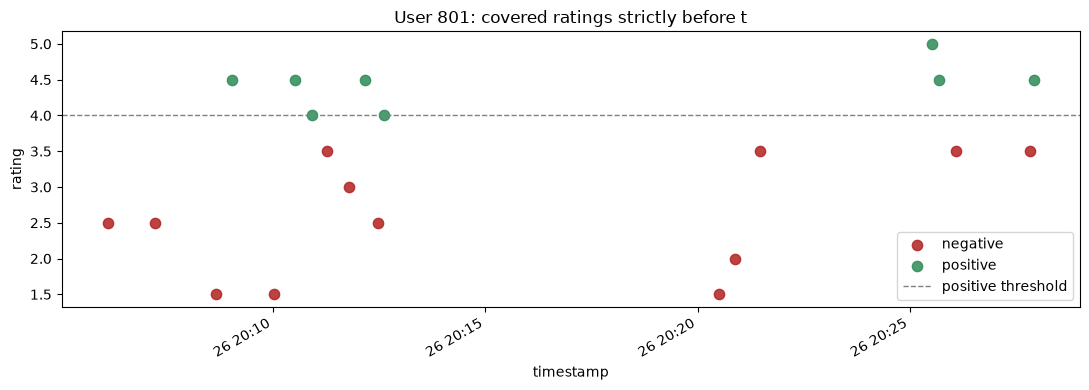

In [35]:
all_prior_genome_history = example_events.loc[
    example_events['timestamp'].lt(genome_t),
    ['ratingEventId', 'timestamp', 'movieId', 'rating'],
].copy()
events_at_genome_t = example_events.loc[
    example_events['timestamp'].eq(genome_t), ['ratingEventId']
].copy()
genome_history = all_prior_genome_history.loc[
    all_prior_genome_history['movieId'].isin(genome_lookup.movie_to_row)
].copy()
genome_history['title'] = genome_history['movieId'].map(movie_titles)
genome_history['group'] = np.where(
    genome_history['rating'].ge(4.0), 'positive', 'negative'
)
positive_history = genome_history.loc[genome_history['group'].eq('positive')].copy()
negative_history = genome_history.loc[genome_history['group'].eq('negative')].copy()

assert all_prior_genome_history['timestamp'].lt(genome_t).all()
assert not all_prior_genome_history['timestamp'].eq(genome_t).any()
assert set(events_at_genome_t['ratingEventId']).isdisjoint(genome_history['ratingEventId'])
assert genome_history['movieId'].isin(genome_lookup.movie_to_row).all()
assert len(positive_history) == int(genome_candidate['positive_history_count'])
assert len(negative_history) == int(genome_candidate['negative_history_count'])

print(
    f'Covered history used: {len(genome_history)} rows '
    f'({len(positive_history)} positive, {len(negative_history)} negative)'
)
print(
    'Prior rows skipped for missing/incomplete Genome coverage: '
    f'{len(all_prior_genome_history) - len(genome_history)}'
)
display(genome_history[['timestamp', 'movieId', 'title', 'rating', 'group']])

figure, axis = plt.subplots(figsize=(11, 4))
colors = {'positive': 'seagreen', 'negative': 'firebrick'}
for group_name, group_rows in genome_history.groupby('group', sort=False):
    axis.scatter(
        group_rows['timestamp'], group_rows['rating'],
        label=group_name, color=colors[group_name], s=55, alpha=0.85,
    )
axis.axhline(4.0, color='gray', linestyle='--', linewidth=1, label='positive threshold')
axis.set_xlabel('timestamp')
axis.set_ylabel('rating')
axis.set_title(f'User {int(genome_event.userId)}: covered ratings strictly before t')
axis.legend()
figure.autofmt_xdate()
figure.tight_layout()
plt.show()

### C. What Genome characteristics describe those two histories?

Each covered movie contributes its raw 1,128-tag vector with equal weight. The implementation adds these vectors separately. Here `positive_profile` and `negative_profile` are the L2-normalized directions of those exact sums—the directions used by cosine similarity. The ten tags have the largest absolute difference between directions; this explains the profiles and is not feature importance.

,tagId,genome tag,positive profile,negative profile,positive - negative
0,19,action,0.038503,0.093123,-0.054621
1,255,cool,0.036146,0.083130,-0.046985
2,100,bad plot,0.025299,0.064683,-0.039385
3,447,good action,0.024380,0.062445,-0.038065
4,535,imagination,0.049386,0.012238,0.037148
5,55,amazing photography,0.063842,0.027160,0.036682
6,402,foreign,0.057470,0.021131,0.036338
7,807,predictable,0.039194,0.075227,-0.036033
8,415,fun movie,0.032589,0.066804,-0.034214
9,20,action packed,0.026806,0.060709,-0.033903


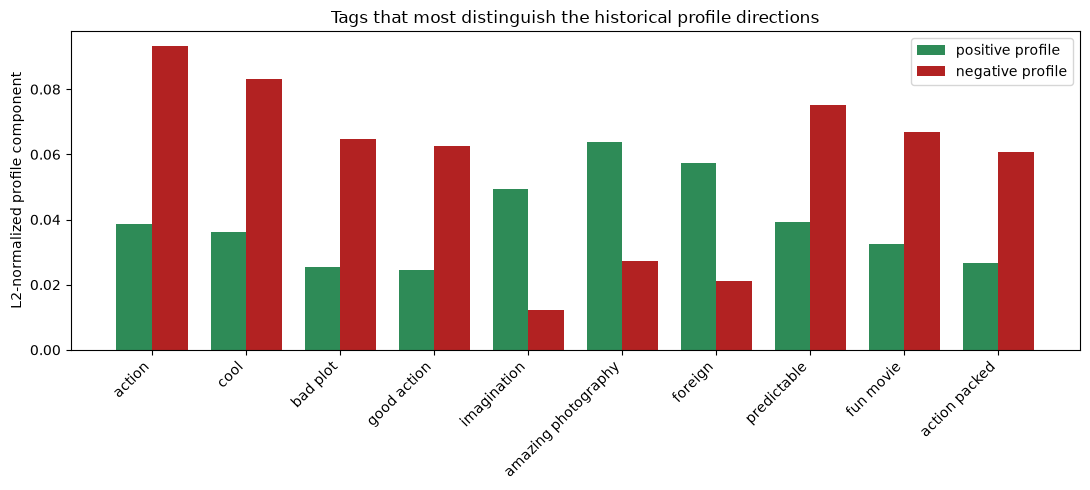

In [36]:
def sum_raw_genome_vectors(history_rows):
    vector_sum = np.zeros(len(genome_lookup.tag_ids), dtype=np.float64)
    for movie_id in history_rows['movieId']:
        vector_sum += genome_lookup.raw_vectors[
            genome_lookup.movie_to_row[int(movie_id)]
        ]
    return vector_sum

positive_sum = sum_raw_genome_vectors(positive_history)
negative_sum = sum_raw_genome_vectors(negative_history)
positive_profile = positive_sum / np.linalg.norm(positive_sum)
negative_profile = negative_sum / np.linalg.norm(negative_sum)
tag_names = genome_tags.set_index('tagId')['tag'].to_dict()
profile_difference = positive_profile - negative_profile
top_difference_positions = np.argsort(np.abs(profile_difference))[-10:][::-1]
profile_tags = pd.DataFrame({
    'tagId': [genome_lookup.tag_ids[p] for p in top_difference_positions],
    'genome tag': [tag_names[genome_lookup.tag_ids[p]] for p in top_difference_positions],
    'positive profile': positive_profile[top_difference_positions],
    'negative profile': negative_profile[top_difference_positions],
    'positive - negative': profile_difference[top_difference_positions],
})
display(profile_tags)

plot_positions = np.arange(len(profile_tags))
bar_width = 0.38
figure, axis = plt.subplots(figsize=(11, 5))
axis.bar(
    plot_positions - bar_width / 2, profile_tags['positive profile'],
    bar_width, label='positive profile', color='seagreen',
)
axis.bar(
    plot_positions + bar_width / 2, profile_tags['negative profile'],
    bar_width, label='negative profile', color='firebrick',
)
axis.set_xticks(plot_positions, profile_tags['genome tag'], rotation=45, ha='right')
axis.set_ylabel('L2-normalized profile component')
axis.set_title('Tags that most distinguish the historical profile directions')
axis.legend()
figure.tight_layout()
plt.show()

### D. What does the target movie look like in Genome space?

The target movie has raw Genome relevance scores and a corresponding L2-normalized vector used for cosine calculations. Its ten largest raw relevance values provide a compact description.

In [37]:
target_row = genome_lookup.movie_to_row[genome_target_movie_id]
target_raw_vector = genome_lookup.raw_vectors[target_row].astype(np.float64, copy=False)
target_normalized_vector = genome_lookup.normalized_vectors[target_row].astype(
    np.float64, copy=False
)
top_target_positions = np.argsort(target_raw_vector)[-10:][::-1]
target_tags = pd.DataFrame({
    'genome tag': [tag_names[genome_lookup.tag_ids[p]] for p in top_target_positions],
    'movie relevance': target_raw_vector[top_target_positions],
})
print(
    f'Target movie: {movie_titles.get(genome_target_movie_id, "(title unavailable)")} '
    f'(movieId={genome_target_movie_id})'
)
display(target_tags)

Target movie: Ocean's Eleven (2001) (movieId=4963)


,genome tag,movie relevance
0,heist,0.99875
1,caper,0.99700
2,cool,0.97900
3,las vegas,0.97725
4,con men,0.97675
5,entertaining,0.97500
6,casino,0.97425
7,con artists,0.97325
8,ensemble cast,0.97325
9,fun movie,0.95900


### E. Which profile is the movie closer to?

Production takes the dot product between the normalized target vector and each historical vector sum, divided by the sum's L2 norm. The manual values are compared with the exact training columns. The scatter below compares the relevance of every Genome tag in the positive user profile `p+` with the relevance of the same tag in the target movie `g_movie`. Greater alignment along the diagonal means the two profiles are more similar.

,similarity,dataset value,manually recomputed value,match
0,genome_user_positive_cosine,0.784841,0.784841,True
1,genome_user_negative_cosine,0.865814,0.865814,True


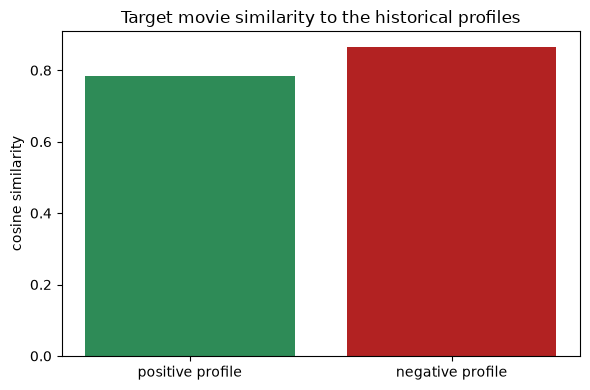

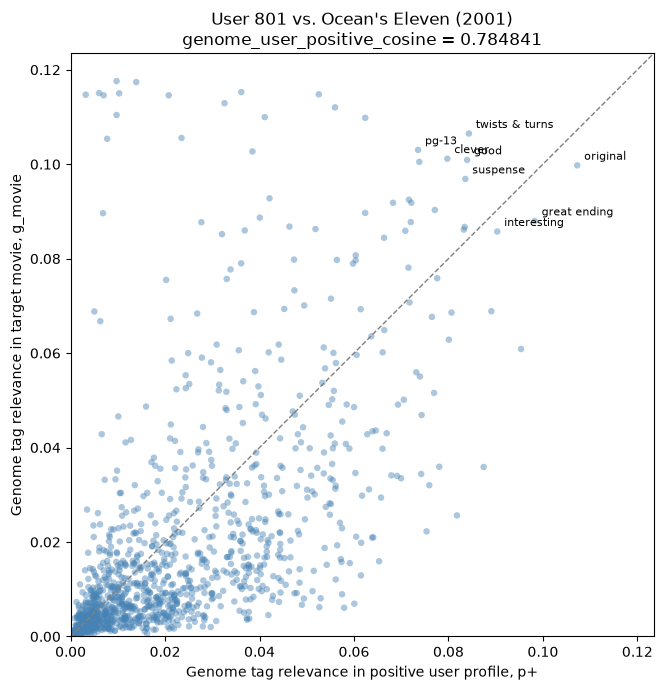

In [38]:
manual_positive_cosine = float(
    np.dot(target_normalized_vector, positive_sum) / np.linalg.norm(positive_sum)
)
manual_negative_cosine = float(
    np.dot(target_normalized_vector, negative_sum) / np.linalg.norm(negative_sum)
)
dataset_positive_cosine = float(genome_event['genome_user_positive_cosine'])
dataset_negative_cosine = float(genome_event['genome_user_negative_cosine'])
cosine_validation = pd.DataFrame({
    'similarity': ['genome_user_positive_cosine', 'genome_user_negative_cosine'],
    'dataset value': [dataset_positive_cosine, dataset_negative_cosine],
    'manually recomputed value': [manual_positive_cosine, manual_negative_cosine],
    'match': [
        np.isclose(manual_positive_cosine, dataset_positive_cosine, rtol=1e-6, atol=1e-6),
        np.isclose(manual_negative_cosine, dataset_negative_cosine, rtol=1e-6, atol=1e-6),
    ],
})
display(cosine_validation)
assert cosine_validation['match'].all()

figure, axis = plt.subplots(figsize=(6, 4))
axis.bar(
    ['positive profile', 'negative profile'],
    [manual_positive_cosine, manual_negative_cosine],
    color=['seagreen', 'firebrick'],
)
axis.set_ylabel('cosine similarity')
axis.set_title('Target movie similarity to the historical profiles')
figure.tight_layout()
plt.show()

tag_contributions = positive_profile * target_normalized_vector
label_positions = np.argsort(tag_contributions)[-8:][::-1]
plot_limit = float(max(positive_profile.max(), target_normalized_vector.max()) * 1.05)

figure, axis = plt.subplots(figsize=(8, 7))
axis.scatter(
    positive_profile, target_normalized_vector,
    s=22, alpha=0.45, color='steelblue', edgecolors='none',
)
axis.plot([0, plot_limit], [0, plot_limit], '--', color='gray', linewidth=1)
for position in label_positions:
    tag_id = genome_lookup.tag_ids[position]
    axis.annotate(
        tag_names[tag_id],
        (positive_profile[position], target_normalized_vector[position]),
        xytext=(5, 4), textcoords='offset points', fontsize=8,
    )
axis.set_xlim(0, plot_limit)
axis.set_ylim(0, plot_limit)
axis.set_aspect('equal', adjustable='box')
axis.set_xlabel('Genome tag relevance in positive user profile, p+')
axis.set_ylabel('Genome tag relevance in target movie, g_movie')
axis.set_title(
    f'User {int(genome_event.userId)} vs. {movie_titles.get(genome_target_movie_id)}\n'
    f'genome_user_positive_cosine = {dataset_positive_cosine:.6f}'
)
figure.tight_layout()
plt.show()

### F. How does that become `genome_preference_margin`?

The definition is `genome_user_positive_cosine - genome_user_negative_cosine`. A positive margin means the target movie is closer to the positive profile; a negative margin means it is closer to the negative profile; near zero means comparable similarity.

In [39]:
manual_margin = manual_positive_cosine - manual_negative_cosine
dataset_margin = float(genome_event['genome_preference_margin'])
margin_match = bool(
    np.isclose(manual_margin, dataset_margin, rtol=1e-6, atol=1e-6)
)
margin_validation = pd.DataFrame({
    'component': [
        'positive cosine', 'negative cosine',
        'recomputed margin', 'dataset margin',
    ],
    'value': [
        manual_positive_cosine, manual_negative_cosine,
        manual_margin, dataset_margin,
    ],
})
display(margin_validation)
print(
    f'{manual_positive_cosine:.6f} - {manual_negative_cosine:.6f} '
    f'= {manual_margin:.6f}'
)
assert margin_match
assert int(genome_event['ratingEventId']) not in set(genome_history['ratingEventId'])
assert not genome_history['timestamp'].eq(genome_t).any()
assert pq.ParquetFile(
    prd_config.FEATURE_ARTIFACT_PATH
).metadata.num_rows == training_rows_before_eda
print('Genome end-to-end reconstruction and temporal checks: PASS')

outcome_connection = pd.Series({
    'genome_preference_margin': dataset_margin,
    'rating observed after feature construction': float(genome_event['rating']),
    'target': int(genome_event['target']),
}, name='value')
display(outcome_connection.to_frame())

,component,value
0,positive cosine,0.784841
1,negative cosine,0.865814
2,recomputed margin,-0.080973
3,dataset margin,-0.080973


0.784841 - 0.865814 = -0.080973
Genome end-to-end reconstruction and temporal checks: PASS


,value
genome_preference_margin,-0.080973
rating observed after feature construction,2.500000
target,0.000000


The missing-value behavior is deliberate. A target movie without a complete, nonzero Genome vector receives `NaN` for all eight Genome features. Covered historical movies accumulate; uncovered ones are ignored. With no covered positive history, the positive cosine is `NaN`; the analogous rule applies to negative history. The margin exists only when both cosines are finite—there is no minimum-history threshold beyond a valid vector sum on each side and no fitted fallback.

### G. Does the feature show signal across the dataset?

The model receives the Genome preference information before observing the displayed rating; that rating is the later outcome to predict. This row illustrates the calculation, not statistical evidence.

For global context, the full non-null dataset is divided into approximately ten quantile bins. The line shows observed high-rating rate by bin. This is descriptive association, not causation.

,bin,mean margin,positive rate,n
0,D1,-0.103792,0.141971,1914998
1,D2,-0.053741,0.229114,1914997
2,D3,-0.032195,0.323370,1914999
3,D4,-0.016725,0.408091,1914997
4,D5,-0.003995,0.486360,1914998
5,D6,0.007828,0.557387,1914998
6,D7,0.020236,0.621967,1914997
7,D8,0.034983,0.682008,1914998
8,D9,0.055686,0.746355,1914998
9,D10,0.109727,0.823578,1914998


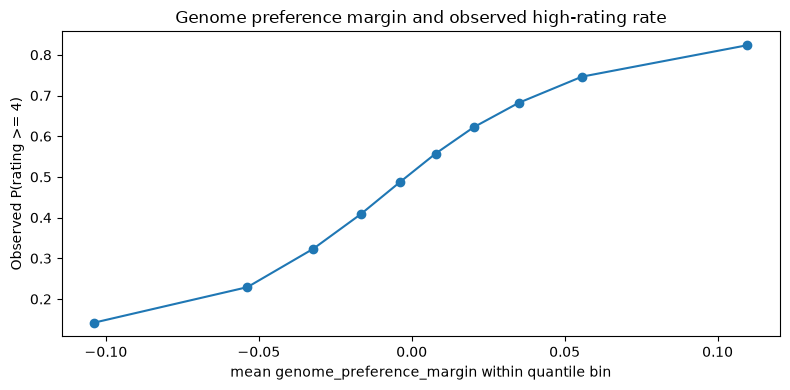

In [40]:
full_margin = pd.read_parquet(
    prd_config.FEATURE_ARTIFACT_PATH, columns=['genome_preference_margin']
)['genome_preference_margin'].dropna()
_, decile_edges = pd.qcut(full_margin, q=10, retbins=True, duplicates='drop')
del full_margin
gc.collect()

bin_count = len(decile_edges) - 1
bin_n = np.zeros(bin_count, dtype=np.int64)
bin_margin_sum = np.zeros(bin_count, dtype=np.float64)
bin_positive_sum = np.zeros(bin_count, dtype=np.int64)
for batch in pq.ParquetFile(prd_config.FEATURE_ARTIFACT_PATH).iter_batches(
    batch_size=250_000,
    columns=['ratingEventId', 'genome_preference_margin'],
):
    part = batch.to_pandas()
    valid = part['genome_preference_margin'].notna()
    margins = part.loc[valid, 'genome_preference_margin'].to_numpy(dtype=np.float64)
    positions = part.loc[valid, 'ratingEventId'].to_numpy(dtype=np.uint64) - 1
    bin_ids = np.searchsorted(decile_edges[1:-1], margins, side='right')
    bin_n += np.bincount(bin_ids, minlength=bin_count)
    bin_margin_sum += np.bincount(bin_ids, weights=margins, minlength=bin_count)
    observed_target = (
        rating_values[positions] >= prd_config.PRD_TARGET_THRESHOLD
    ).astype(np.int8)
    bin_positive_sum += np.bincount(
        bin_ids, weights=observed_target, minlength=bin_count
    ).astype(np.int64)

margin_deciles = pd.DataFrame({
    'bin': [f'D{number}' for number in range(1, bin_count + 1)],
    'mean margin': bin_margin_sum / bin_n,
    'positive rate': bin_positive_sum / bin_n,
    'n': bin_n,
})
display(margin_deciles)
assert int(bin_n.sum()) == int(
    feature_summary.loc['genome_preference_margin', 'count']
)

figure, axis = plt.subplots(figsize=(8, 4))
axis.plot(
    margin_deciles['mean margin'], margin_deciles['positive rate'], marker='o'
)
axis.set_xlabel('mean genome_preference_margin within quantile bin')
axis.set_ylabel('Observed P(rating >= 4)')
axis.set_title('Genome preference margin and observed high-rating rate')
figure.tight_layout()
plt.show()